# EU Regional and City-Proxy Wage-Cost Analysis

This notebook extends the city-premium question to the European Union.

The EU case requires more care than the US case. There is no single harmonised, annually updated, city-level dataset that gives wages by occupation and local cost of living for all EU cities.

The design therefore uses a transparent hierarchy:

1. **Regional income layer**: Eurostat NUTS2 household income and compensation-of-employees datasets.
2. **Cross-country price layer**: Eurostat price level indices / purchasing power parities.
3. **City proxy layer**: map major cities to NUTS2 regions.
4. **Optional urban layer**: Eurostat Urban Audit datasets, where coverage is available.

The result is not a perfect city-level cost-of-living model. It is a reproducible way to test whether high-income EU capital regions still look attractive after adjusting for national purchasing-power differences.

> **Headline (Eurostat NUTS2 disposable income per inhabitant + national price levels).** Nominal income and real living standards rank Europe's capital-regions very differently. Munich leads on price-adjusted income; high-cost Dublin and Copenhagen fall ~85+ rank places; and low-price Eastern capitals (Bucharest, Budapest, Warsaw, Prague) are the big real gainers and tower over their own countries — while Berlin, Vienna and Brussels sit *below* their national median region.

## Research design

The main adjustment is:

\[
\text{real income}_{r} = \frac{\text{income}_{r}}{\text{country price level index}/100}
\]

Where:

- \(r\) is a NUTS2 region;
- income is disposable household income or compensation of employees;
- the price level index is usually available at country level.

This means the model captures **between-country price differences** better than **within-country city cost differences**.

For within-country city cost pressure, housing data is the missing variable. The notebook is structured so that local rent or housing-cost data can be merged later.

## Data sources

The notebook uses Eurostat through the `eurostat` Python package.

Core datasets:

- `nama_10r_2hhinc`: income of households by NUTS2 region.
- `nama_10r_2coe`: compensation of employees by NUTS2 region.
- `tec00120`: price level indices.

Optional datasets:

- Eurostat City Statistics / Urban Audit datasets, when needed and available.

Eurostat schemas can change. The notebook includes inspection helpers so the filters are explicit.

In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

In [2]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HOUSEHOLD_INCOME_DATASET = "nama_10r_2hhinc"
COMPENSATION_DATASET = "nama_10r_2coe"
PRICE_LEVEL_DATASET = "tec00120"

# Major city proxies. These are NUTS2 regions that contain or approximate major cities.
# The notebook keeps only regions present in the downloaded Eurostat data.
CITY_REGION_MAP = pd.DataFrame(
    [
        ("Lisbon", "Portugal", "PT17"),
        ("Porto / Norte", "Portugal", "PT11"),
        ("Madrid", "Spain", "ES30"),
        ("Barcelona / Catalonia", "Spain", "ES51"),
        ("Paris / Île-de-France", "France", "FR10"),
        ("Milan / Lombardia", "Italy", "ITC4"),
        ("Rome / Lazio", "Italy", "ITI4"),
        ("Berlin", "Germany", "DE30"),
        ("Munich / Oberbayern", "Germany", "DE21"),
        ("Amsterdam / Noord-Holland", "Netherlands", "NL32"),
        ("Rotterdam / Zuid-Holland", "Netherlands", "NL33"),
        ("Brussels", "Belgium", "BE10"),
        ("Dublin / Eastern and Midland", "Ireland", "IE06"),
        ("Copenhagen / Hovedstaden", "Denmark", "DK01"),
        ("Stockholm", "Sweden", "SE11"),
        ("Helsinki-Uusimaa", "Finland", "FI1B"),
        ("Vienna", "Austria", "AT13"),
        ("Warsaw", "Poland", "PL91"),
        ("Prague", "Czechia", "CZ01"),
        ("Budapest", "Hungary", "HU11"),
        ("Athens / Attiki", "Greece", "EL30"),
        ("Bucharest-Ilfov", "Romania", "RO32"),
    ],
    columns=["city_proxy", "country_name", "geo"],
)

In [3]:
# ---------------------------------------------------------------------
# Eurostat utilities
# ---------------------------------------------------------------------

def assert_dataframe(value: pd.DataFrame, name: str) -> None:
    """Validate that a value is a pandas DataFrame."""
    if not isinstance(value, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame")


def assert_non_empty_string(value: str, name: str) -> None:
    """Validate that a value is a non-empty string."""
    if not isinstance(value, str) or not value.strip():
        raise TypeError(f"{name} must be a non-empty string")


def load_eurostat_dataset(dataset_code: str, *, refresh: bool = False) -> pd.DataFrame:
    """Load a Eurostat dataset with a parquet cache.

    The `eurostat` package downloads public Eurostat data and returns a wide DataFrame.
    """
    assert_non_empty_string(dataset_code, "dataset_code")
    path = RAW_DIR / f"{dataset_code}.parquet"
    if path.exists() and not refresh:
        return pd.read_parquet(path)

    import eurostat

    df = eurostat.get_data_df(dataset_code, flags=False)
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise ValueError(f"Eurostat dataset {dataset_code} returned no data")
    df.to_parquet(path, index=False)
    return df


def normalize_column_name(name: object) -> str:
    """Normalize column names while preserving year columns."""
    text = str(name).strip()
    if re.fullmatch(r"\d{4}", text):
        return text
    text = text.lower().replace("\\time_period", "")
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with normalized columns."""
    assert_dataframe(df, "df")
    out = df.copy()
    out.columns = [normalize_column_name(c) for c in out.columns]
    return out


def year_columns(df: pd.DataFrame) -> list[str]:
    """Return columns that look like year labels."""
    return [str(c) for c in df.columns if re.fullmatch(r"\d{4}", str(c))]


def eurostat_wide_to_long(df: pd.DataFrame, value_name: str = "value") -> pd.DataFrame:
    """Convert a Eurostat wide DataFrame to long format."""
    assert_dataframe(df, "df")
    x = normalize_columns(df)
    years = year_columns(x)
    if not years:
        raise ValueError("No year columns were detected. Inspect the Eurostat schema.")
    id_cols = [c for c in x.columns if c not in years]
    out = x.melt(id_vars=id_cols, value_vars=years, var_name="year", value_name=value_name)
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    return out.dropna(subset=[value_name, "year"])


def summarize_dimensions(df: pd.DataFrame, max_values: int = 20) -> None:
    """Print compact dimension summaries for a Eurostat DataFrame."""
    assert_dataframe(df, "df")
    x = normalize_columns(df)
    years = set(year_columns(x))
    for col in x.columns:
        if col in years:
            continue
        values = sorted(x[col].dropna().astype(str).unique().tolist())[:max_values]
        print(f"{col}: {values}")


def filter_existing(df: pd.DataFrame, **filters: str | Sequence[str]) -> pd.DataFrame:
    """Filter only on columns that exist.

    This allows the notebook to survive small Eurostat schema differences.
    """
    assert_dataframe(df, "df")
    out = df.copy()
    for col, allowed in filters.items():
        if col not in out.columns:
            continue
        allowed_values = [allowed] if isinstance(allowed, str) else list(allowed)
        out = out[out[col].astype(str).isin([str(v) for v in allowed_values])]
    return out


def latest_by_geo(df: pd.DataFrame, value_col: str = "value") -> pd.DataFrame:
    """Keep the latest available observation per geo."""
    assert_dataframe(df, "df")
    if "geo" not in df.columns:
        raise KeyError("Expected a `geo` column")
    out = df.dropna(subset=[value_col]).copy()
    out = out.sort_values(["geo", "year"])
    return out.groupby("geo", as_index=False).tail(1).reset_index(drop=True)

In [4]:
# ---------------------------------------------------------------------
# Download and inspect Eurostat datasets
# ---------------------------------------------------------------------

hh_wide = load_eurostat_dataset(HOUSEHOLD_INCOME_DATASET)
coe_wide = load_eurostat_dataset(COMPENSATION_DATASET)
pli_wide = load_eurostat_dataset(PRICE_LEVEL_DATASET)

print("Household income dimensions")
summarize_dimensions(hh_wide)
print("\nCompensation dimensions")
summarize_dimensions(coe_wide)
print("\nPrice-level dimensions")
summarize_dimensions(pli_wide)

print("\nShapes:", hh_wide.shape, coe_wide.shape, pli_wide.shape)
display(hh_wide.head())
display(pli_wide.head())

Household income dimensions
freq: ['A']
unit: ['EUR_HAB', 'MIO_EUR', 'MIO_NAC', 'MIO_PPS_EU27_2020', 'PPS_EU27_2020_HAB']
direct: ['BAL', 'PAID', 'RECV']
na_item: ['B2A3N', 'B5N', 'B6N', 'B7N', 'D1', 'D4', 'D5', 'D61', 'D62', 'D63', 'D7', 'P3', 'P51C']
geo: ['AT', 'AT1', 'AT11', 'AT12', 'AT13', 'AT2', 'AT21', 'AT22', 'AT3', 'AT31', 'AT32', 'AT33', 'AT34', 'ATZ', 'ATZZ', 'BE', 'BE1', 'BE10', 'BE2', 'BE21']

Compensation dimensions
freq: ['A']
currency: ['MIO_EUR', 'MIO_NAC']
nace_r2: ['A', 'B-E', 'C', 'F', 'G-I', 'G-J', 'J', 'K', 'K-N', 'L', 'M_N', 'O-Q', 'O-U', 'R-U', 'TOTAL']
geo: ['AT', 'AT1', 'AT11', 'AT12', 'AT13', 'AT2', 'AT21', 'AT22', 'AT3', 'AT31', 'AT32', 'AT33', 'AT34', 'ATZ', 'ATZZ', 'BE', 'BE1', 'BE10', 'BE2', 'BE21']

Price-level dimensions
freq: ['A']
indic_ppp: ['PLI_EU27_2020']
ppp_cat18: ['E011']
geo: ['AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EA19', 'EA20', 'EA21', 'EE', 'EL', 'ES', 'EU27_2020', 'FI', 'FR', 'HR']

Shapes: (12372, 30) (12096, 29) (43

,freq,unit,direct,na_item,geo\TIME_PERIOD,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,A,EUR_HAB,BAL,B5N,AT,17900.0,18100.0,18200.0,18700.0,19400.0,20200.0,21300.0,22400.0,23200.0,22700.0,22700.0,23200.0,24300.0,24200.0,24600.0,25100.0,25300.0,26100.0,27200.0,27800.0,26700.0,28300.0,30600.0,32600.0,34600.0
1,A,EUR_HAB,BAL,B5N,AT1,19000.0,19100.0,19100.0,19500.0,20100.0,20800.0,21800.0,23000.0,23800.0,23300.0,23200.0,23600.0,24500.0,24300.0,24600.0,25100.0,25200.0,25800.0,26900.0,27400.0,26400.0,28000.0,30200.0,32100.0,34000.0
2,A,EUR_HAB,BAL,B5N,AT11,15800.0,16100.0,16400.0,17100.0,18300.0,19200.0,20200.0,21300.0,22000.0,21600.0,21700.0,22100.0,23400.0,23100.0,23600.0,24400.0,24400.0,25500.0,26400.0,26900.0,26100.0,27600.0,29600.0,31200.0,33100.0
3,A,EUR_HAB,BAL,B5N,AT12,18100.0,18400.0,18500.0,19100.0,19800.0,20700.0,21800.0,23000.0,23900.0,23400.0,23500.0,24100.0,25200.0,25100.0,25500.0,26100.0,26400.0,27100.0,28300.0,28800.0,27900.0,29400.0,31600.0,33600.0,35500.0
4,A,EUR_HAB,BAL,B5N,AT13,20400.0,20300.0,20200.0,20300.0,20600.0,21200.0,22200.0,23200.0,24000.0,23500.0,23200.0,23400.0,24100.0,23700.0,23900.0,24200.0,24200.0,24600.0,25700.0,26300.0,25200.0,26900.0,29100.0,31000.0,32900.0


,freq,indic_ppp,ppp_cat18,geo\TIME_PERIOD,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,PLI_EU27_2020,E011,AL,50.1,48.3,51.1,52.4,55.9,58.3,59.4,61.6,61.9,65.2,70.6,72.6
1,A,PLI_EU27_2020,E011,AT,109.3,109.3,110.4,111.6,112.1,113.2,111.7,108.5,107.9,111.5,111.7,113.0
2,A,PLI_EU27_2020,E011,BA,54.5,53.8,53.3,54.5,54.8,54.8,56.1,56.2,58.4,58.4,58.4,59.2
3,A,PLI_EU27_2020,E011,BE,111.2,111.2,113.3,114.3,114.7,114.9,113.6,115.5,117.4,116.9,116.7,116.2
4,A,PLI_EU27_2020,E011,BG,49.3,49.7,49.7,51.2,51.9,53.6,55.2,55.5,58.2,59.2,60.5,62.5


## Select income and price indicators

Eurostat datasets often expose multiple units and national-accounts items. The code below uses sensible defaults, but it prints the available dimensions above so you can adjust them.

For household income, the preferred choice is usually disposable income per inhabitant, ideally in EUR or PPS per inhabitant.

For price levels, the preferred choice is the household final consumption price-level index where available.

In [5]:
hh_long = eurostat_wide_to_long(hh_wide, value_name="household_income")
coe_long = eurostat_wide_to_long(coe_wide, value_name="compensation")
pli_long = eurostat_wide_to_long(pli_wide, value_name="price_level_index")

# Normalized column names after melting.
hh_long = normalize_columns(hh_long)
coe_long = normalize_columns(coe_long)
pli_long = normalize_columns(pli_long)

# Household income: pick ONE consistent measure so regions are comparable.
#   direct  = BAL      -> the income balance (not a paid/received sub-flow)
#   na_item = B6N      -> net disposable income of households
#   unit    = EUR_HAB  -> euro *per inhabitant*
# This is the critical choice. The same dataset also carries MIO_EUR (millions of
# euro, i.e. the whole-region total). Mixing the two would compare per-person
# income in one region against a region-wide total in another and rank the
# largest regions first -- a per-capita vs total units trap.
hh_filtered = filter_existing(
    hh_long,
    direct=["BAL"],
    na_item=["B6N"],
    unit=["EUR_HAB"],
)

# Compensation of employees (kept for optional extension; not used downstream).
coe_filtered = filter_existing(coe_long, currency=["MIO_EUR"], nace_r2=["TOTAL"])

# Price-level index: tec00120 exposes a single indicator (PLI_EU27_2020) and a
# single category (E011, actual individual consumption), so no filter is needed.
pli_filtered = pli_long.copy()

if hh_filtered.empty:
    raise ValueError(
        "Household-income filters returned no rows. Inspect the dimensions "
        "printed above and adjust direct/na_item/unit."
    )

hh_latest = latest_by_geo(hh_filtered, "household_income")
pli_latest = latest_by_geo(pli_filtered, "price_level_index")

# Keep NUTS2 regions only (4-character geo codes such as FR10, ES30, ITC4) so
# the ranking compares like with like and does not mix country, NUTS1 and NUTS2
# levels. The mapped city proxies are all NUTS2.
hh_latest = hh_latest[hh_latest["geo"].astype(str).str.len() == 4].reset_index(drop=True)

# NUTS2 regions use the country prefix as the first two characters.
hh_latest["country_code"] = hh_latest["geo"].astype(str).str[:2]
pli_latest["country_code"] = pli_latest["geo"].astype(str)

print("NUTS2 regions with income:", hh_latest.shape[0], "| countries with PLI:", pli_latest.shape[0])
print("Income unit:", hh_latest["unit"].unique().tolist(),
      "| na_item:", hh_latest["na_item"].unique().tolist())
display(hh_latest.head())
display(pli_latest.head())

NUTS2 regions with income: 250 | countries with PLI: 43
Income unit: ['EUR_HAB'] | na_item: ['B6N']


,freq,unit,direct,na_item,geo,year,household_income,country_code
0,A,EUR_HAB,BAL,B6N,AT11,2024,31200.0,AT
1,A,EUR_HAB,BAL,B6N,AT12,2024,31600.0,AT
2,A,EUR_HAB,BAL,B6N,AT13,2024,28200.0,AT
3,A,EUR_HAB,BAL,B6N,AT21,2024,30100.0,AT
4,A,EUR_HAB,BAL,B6N,AT22,2024,30700.0,AT


,freq,indic_ppp,ppp_cat18,geo,year,price_level_index,country_code
0,A,PLI_EU27_2020,E011,AL,2025,72.6,AL
1,A,PLI_EU27_2020,E011,AT,2025,113.0,AT
2,A,PLI_EU27_2020,E011,BA,2025,59.2,BA
3,A,PLI_EU27_2020,E011,BE,2025,116.2,BE
4,A,PLI_EU27_2020,E011,BG,2025,62.5,BG


In [6]:
# Join NUTS2 income to country-level price level index.
# If multiple PLI rows per country remain after filtering, keep the latest and first category per country.
pli_country = (
    pli_latest.sort_values(["country_code", "year"])
    .groupby("country_code", as_index=False)
    .tail(1)
    [["country_code", "year", "price_level_index"]]
    .rename(columns={"year": "price_year"})
)

regional = hh_latest.merge(pli_country, on="country_code", how="left")
regional["real_household_income_price_adjusted"] = (
    regional["household_income"] / (regional["price_level_index"] / 100)
)
regional["income_rank_nominal"] = regional["household_income"].rank(ascending=False, method="min")
regional["income_rank_real"] = regional["real_household_income_price_adjusted"].rank(ascending=False, method="min")
regional["rank_change_after_price_adjustment"] = regional["income_rank_nominal"] - regional["income_rank_real"]

regional = regional.sort_values("real_household_income_price_adjusted", ascending=False).reset_index(drop=True)
print(regional.shape)
display(regional.head(30))

(250, 14)


,freq,unit,direct,na_item,geo,year,household_income,country_code,price_year,price_level_index,real_household_income_price_adjusted,income_rank_nominal,income_rank_real,rank_change_after_price_adjustment
0,A,EUR_HAB,BAL,B6N,DE21,2023,34700.0,DE,2025,108.3,32040.627886,2.0,1.0,1.0
1,A,EUR_HAB,BAL,B6N,LU00,2024,41200.0,LU,2025,131.5,31330.798479,1.0,2.0,-1.0
2,A,EUR_HAB,BAL,B6N,ITH1,2024,30300.0,IT,2025,97.1,31204.943357,16.0,3.0,13.0
3,A,EUR_HAB,BAL,B6N,DE11,2023,30800.0,DE,2025,108.3,28439.519852,10.0,4.0,6.0
4,A,EUR_HAB,BAL,B6N,AT12,2024,31600.0,AT,2025,113.0,27964.601770,4.0,5.0,-1.0
5,A,EUR_HAB,BAL,B6N,DE71,2023,30100.0,DE,2025,108.3,27793.167128,17.0,6.0,11.0
6,A,EUR_HAB,BAL,B6N,DE27,2023,30100.0,DE,2025,108.3,27793.167128,17.0,6.0,11.0
7,A,EUR_HAB,BAL,B6N,BE24,2024,32200.0,BE,2025,116.2,27710.843373,3.0,8.0,-5.0
8,A,EUR_HAB,BAL,B6N,DE25,2023,30000.0,DE,2025,108.3,27700.831025,20.0,9.0,11.0
9,A,EUR_HAB,BAL,B6N,DE14,2023,30000.0,DE,2025,108.3,27700.831025,20.0,9.0,11.0


## City proxy comparison

This maps major cities to their NUTS2 regions. The comparison is not a pure city comparison. It is a **city-region proxy**, which is often the best harmonised EU layer available without restricted microdata.

In [7]:
city_proxy = CITY_REGION_MAP.merge(regional, on="geo", how="left")
city_proxy = city_proxy.dropna(subset=["household_income"]).copy()
city_proxy = city_proxy.sort_values("real_household_income_price_adjusted", ascending=False)

display(city_proxy[[
    "city_proxy",
    "country_name",
    "geo",
    "year",
    "household_income",
    "price_level_index",
    "real_household_income_price_adjusted",
    "income_rank_nominal",
    "income_rank_real",
    "rank_change_after_price_adjustment",
]])

,city_proxy,country_name,geo,year,household_income,price_level_index,real_household_income_price_adjusted,income_rank_nominal,income_rank_real,rank_change_after_price_adjustment
8,Munich / Oberbayern,Germany,DE21,2023,34700.0,108.3,32040.627886,2.0,1.0,1.0
5,Milan / Lombardia,Italy,ITC4,2024,26600.0,97.1,27394.438723,61.0,16.0,45.0
21,Bucharest-Ilfov,Romania,RO32,2023,17600.0,65.1,27035.330261,159.0,21.0,138.0
4,Paris / Île-de-France,France,FR10,2023,29600.0,110.3,26835.902085,24.0,28.0,-4.0
16,Vienna,Austria,AT13,2024,28200.0,113.0,24955.752212,38.0,44.0,-6.0
2,Madrid,Spain,ES30,2023,22600.0,91.6,24672.489083,122.0,50.0,72.0
7,Berlin,Germany,DE30,2023,26400.0,108.3,24376.731302,68.0,55.0,13.0
9,Amsterdam / Noord-Holland,Netherlands,NL32,2023,28000.0,115.6,24221.453287,40.0,58.0,-18.0
19,Budapest,Hungary,HU11,2023,18600.0,77.5,24000.000000,151.0,62.0,89.0
15,Helsinki-Uusimaa,Finland,FI1B,2023,28900.0,120.8,23923.841060,31.0,63.0,-32.0


**The price adjustment changes the order.** On nominal income the leaders are
the Nordic, Irish and large Western city-regions. After dividing by the national
price level, **Munich** leads, the high-cost capitals (**Dublin**, **Copenhagen**,
**Stockholm**, **Helsinki**) slide down, and lower-priced **Eastern capitals**
(**Bucharest**, **Budapest**, **Warsaw**, **Prague**) climb dozens of rank
places. The `rank_change_after_price_adjustment` column quantifies each move.

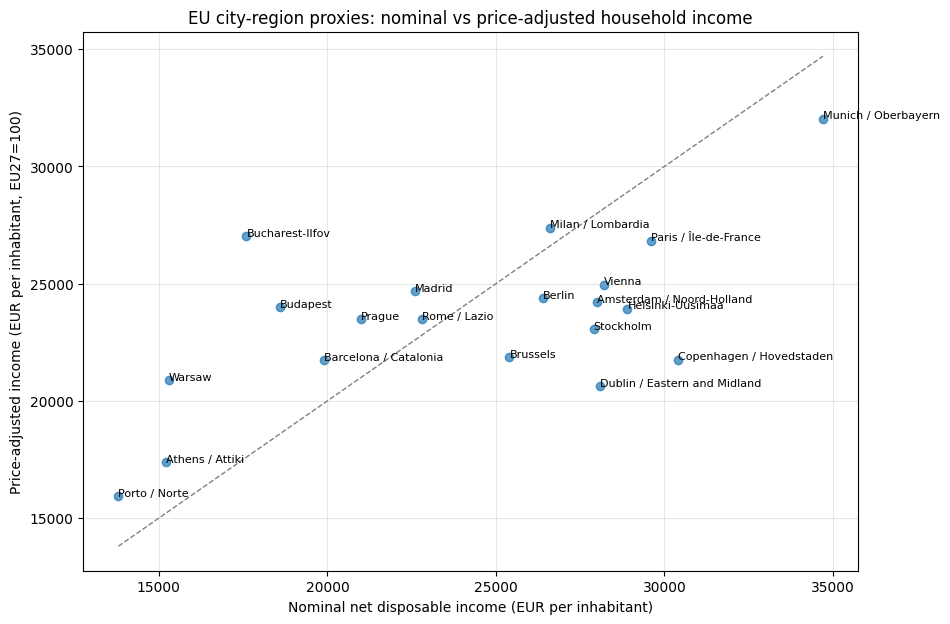

In [8]:
plot_df = city_proxy.dropna(subset=["household_income", "real_household_income_price_adjusted"]).copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(plot_df["household_income"], plot_df["real_household_income_price_adjusted"], alpha=0.7)
lims = [
    min(plot_df["household_income"].min(), plot_df["real_household_income_price_adjusted"].min()),
    max(plot_df["household_income"].max(), plot_df["real_household_income_price_adjusted"].max()),
]
ax.plot(lims, lims, linestyle="--", linewidth=1, color="grey")
for _, row in plot_df.iterrows():
    ax.annotate(row["city_proxy"], (row["household_income"], row["real_household_income_price_adjusted"]), fontsize=8)
ax.set_xlabel("Nominal net disposable income (EUR per inhabitant)")
ax.set_ylabel("Price-adjusted income (EUR per inhabitant, EU27=100)")
ax.set_title("EU city-region proxies: nominal vs price-adjusted household income")
ax.grid(True, alpha=0.3)
plt.show()

**Reading the scatter.** Points far below the 45&deg; line are city-regions
whose nominal income is eroded most by a high national price level: **Dublin**
and **Copenhagen** sit lowest relative to their nominal income. Points that hold
near or above the line (Munich, Milan, and the lower-income Eastern capitals)
keep their income in purchasing-power terms. Nominal euros and real living
standards are not the same ranking.

## Capital-region premium within each country

The next cell compares each mapped city-region with the median region in its country.

This avoids comparing Lisbon directly with Copenhagen without context. It asks a more local question:

> Does the capital or large city-region sit above the country's regional median?

In [9]:
country_medians = (
    regional.groupby("country_code", as_index=False)
    .agg(
        country_median_income=("household_income", "median"),
        country_median_real_income=("real_household_income_price_adjusted", "median"),
    )
)

city_vs_country = city_proxy.merge(country_medians, on="country_code", how="left")
city_vs_country["nominal_premium_vs_country_median"] = (
    city_vs_country["household_income"] - city_vs_country["country_median_income"]
)
city_vs_country["real_premium_vs_country_median"] = (
    city_vs_country["real_household_income_price_adjusted"] - city_vs_country["country_median_real_income"]
)
city_vs_country["real_premium_pct_vs_country_median"] = (
    city_vs_country["real_premium_vs_country_median"]
    / city_vs_country["country_median_real_income"]
    * 100
)

display(city_vs_country[[
    "city_proxy",
    "country_name",
    "geo",
    "household_income",
    "real_household_income_price_adjusted",
    "country_median_real_income",
    "real_premium_vs_country_median",
    "real_premium_pct_vs_country_median",
]].sort_values("real_premium_pct_vs_country_median", ascending=False))

,city_proxy,country_name,geo,household_income,real_household_income_price_adjusted,country_median_real_income,real_premium_vs_country_median,real_premium_pct_vs_country_median
2,Bucharest-Ilfov,Romania,RO32,17600.0,27035.330261,12903.225806,14132.104455,109.523810
8,Budapest,Hungary,HU11,18600.0,24000.000000,13032.258065,10967.741935,84.158416
16,Warsaw,Poland,PL91,15300.0,20873.124147,14870.395634,6002.728513,40.366972
10,Prague,Czechia,CZ01,21000.0,23489.932886,16834.451902,6655.480984,39.534884
3,Paris / Île-de-France,France,FR10,29600.0,26835.902085,21033.544878,5802.357208,27.586207
0,Munich / Oberbayern,Germany,DE21,34700.0,32040.627886,25484.764543,6555.863343,25.724638
12,Stockholm,Sweden,SE11,27900.0,23057.851240,18512.396694,4545.454545,24.553571
5,Madrid,Spain,ES30,22600.0,24672.489083,19978.165939,4694.323144,23.497268
18,Athens / Attiki,Greece,EL30,15200.0,17391.304348,14187.643021,3203.661327,22.580645
9,Helsinki-Uusimaa,Finland,FI1B,28900.0,23923.841060,19619.205298,4304.635762,21.940928


**Capital-vs-country reveals two Europes.** In Central and Eastern Europe the
capital region towers over the rest of the country &mdash; Bucharest sits ~110%
above Romania's median NUTS2 region in real terms, Budapest ~84%, Warsaw and
Prague ~40%. In several Western countries the "capital" region is *not* the
richest: Vienna, Berlin and Brussels fall slightly **below** their national
median. The Brussels figure is an artefact worth flagging &mdash; commuters'
income is recorded in their home regions, deflating the city-region total.

## Optional: add local rent or housing-cost data

The biggest limitation in the EU analysis is within-country city cost. National PPP adjustment does not capture the fact that Madrid is more expensive than many Spanish regions, or that Paris is very different from provincial France.

To improve this, create a CSV at:

```text
data/manual/eu_city_housing_costs.csv
```

with columns:

```text
city_proxy,monthly_rent,annual_housing_cost,cost_currency,source,year
```

Then rerun the next cell.

In [10]:
housing_path = DATA_DIR / "manual" / "eu_city_housing_costs.csv"

if housing_path.exists():
    housing_costs = pd.read_csv(housing_path)
    required_cols = {"city_proxy", "annual_housing_cost"}
    missing = required_cols.difference(housing_costs.columns)
    if missing:
        raise KeyError(f"Housing-cost file is missing columns: {sorted(missing)}")

    enriched = city_vs_country.merge(housing_costs, on="city_proxy", how="left")
    enriched["income_after_housing_proxy"] = (
        enriched["real_household_income_price_adjusted"] - enriched["annual_housing_cost"]
    )
    display(enriched.sort_values("income_after_housing_proxy", ascending=False))
else:
    print(f"Optional housing-cost file not found: {housing_path}")
    print("The notebook will continue with price-adjusted regional income only.")

Optional housing-cost file not found: C:\Users\diogo\work_code\ds-projects-portfolio\projects\city_wage_cost_global\data\manual\eu_city_housing_costs.csv
The notebook will continue with price-adjusted regional income only.


## Optional: load Eurostat Urban Audit datasets

Eurostat City Statistics / Urban Audit has many city-level variables, but coverage is uneven by country and year. Use this helper when you want to add a specific city-level variable.

Examples of possible Urban Audit datasets can be explored from Eurostat's City Statistics database.

In [11]:
def load_urban_audit_dataset(dataset_code: str, *, refresh: bool = False) -> pd.DataFrame:
    """Load an optional Eurostat Urban Audit / City Statistics dataset."""
    assert_non_empty_string(dataset_code, "dataset_code")
    return load_eurostat_dataset(dataset_code, refresh=refresh)

# Example usage after choosing a dataset code from Eurostat:
# urban = load_urban_audit_dataset("urb_cpop1")
# summarize_dimensions(urban)
# display(urban.head())

## Save outputs

The saved CSV can be used in the comparative notebook.

In [12]:
out_path = OUTPUT_DIR / "eu_region_city_proxy_income_cost_analysis.csv"
city_vs_country.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: C:\Users\diogo\work_code\ds-projects-portfolio\projects\city_wage_cost_global\outputs\eu_region_city_proxy_income_cost_analysis.csv


## Conclusion: the capital is not automatically the richest place to live

Using Eurostat net disposable household income per inhabitant (`nama_10r_2hhinc`,
B6N, EUR per inhabitant) and country price-level indices (`tec00120`, EU27=100),
across NUTS2 regions, the city-region premium looks very different before and
after the price adjustment.

**1. The nominal leaders are not the real leaders.** **Copenhagen** and
**Dublin** are near the top on nominal income (~&euro;30k and ~&euro;28k per
inhabitant) but have the highest price levels in the sample (PLI 140 and 136), so
they fall the hardest &mdash; Dublin drops about **88 rank places** and
Copenhagen **83** once prices are netted out. The highest *real* household income
among these city-regions is **Munich** (&euro;32.0k), not the richest nominal
region.

**2. Eastern and southern capitals are the big purchasing-power gainers.** Where
the national price level is low, the capital region's real income jumps:
**Bucharest** rises ~138 rank places (PLI 65), **Budapest** ~89, **Warsaw** ~58,
**Prague** ~70, **Madrid** ~72. In real terms Bucharest sits *above* Paris and
Amsterdam &mdash; a ranking that nominal euros completely hide.

**3. The capital is sometimes below its own country's median region.** Measured
against the median NUTS2 region in the same country, **Bucharest (+110%)**,
**Budapest (+84%)** and **Warsaw/Prague (~+40%)** dominate their nations. But
**Vienna (&minus;8%)**, **Berlin (&minus;4%)**, **Brussels (&minus;10%)** and
**Porto (&minus;10%)** sit *below* their national median. Germany's income is
concentrated in the south (Munich, not Berlin); the Brussels-Capital figure is
depressed because much of its workforce lives &mdash; and its income is counted
&mdash; in Flanders and Wallonia.

> **Bottom line.** Adjusting for national price levels reshuffles Europe's
> capital-regions sharply: the Nordic and Irish capitals are richer on paper than
> in the supermarket, while Central/Eastern European capitals convert a modest
> nominal income into strong local purchasing power. "Move to the capital" is not
> reliable advice even at this coarse resolution.

*Caveat: this adjustment is **between-country** only. It does not capture
within-country city costs &mdash; above all housing, where Munich, Paris and
Amsterdam are far more expensive than their national price index implies. The
optional housing-cost merge in the cell above is where that gap would be closed.
See `METHODOLOGY.md`.*